In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("/Users/sa19/class-projects/Fraud Detection Lab/Data.ipynb/Raw/PS_20174392719_1491204439457_log.csv")

In [3]:
df.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
df.describe().round(2)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6362620.00,6362620.00,6362620.00,6362620.00,6.362620e+06,6.362620e+06,6362620.00,6362620.0
mean,243.40,179861.90,833883.10,855113.67,1.100702e+06,1.224996e+06,0.00,0.0
std,142.33,603858.23,2888242.67,2924048.50,3.399180e+06,3.674129e+06,0.04,0.0
min,1.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
25%,156.00,13389.57,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
50%,239.00,74871.94,14208.00,0.00,1.327057e+05,2.146614e+05,0.00,0.0
75%,335.00,208721.48,107315.18,144258.41,9.430367e+05,1.111909e+06,0.00,0.0
max,743.00,92445516.64,59585040.37,49585040.37,3.560159e+08,3.561793e+08,1.00,1.0


In [6]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

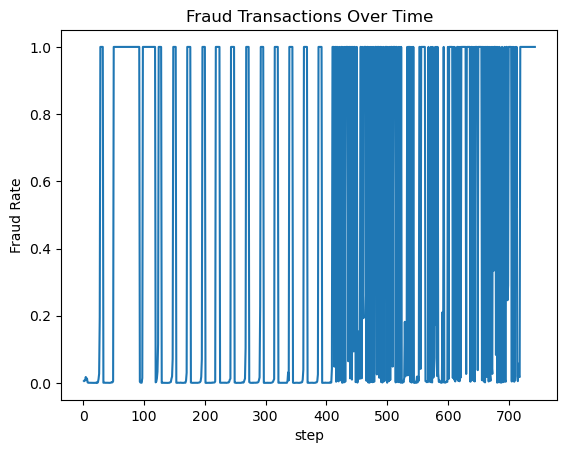

<Figure size 1200x500 with 0 Axes>

In [7]:
sns.lineplot(data=df.groupby('step')['isFraud'].mean().reset_index(), x='step', y='isFraud')
plt.title("Fraud Transactions Over Time")
plt.ylabel("Fraud Rate")
plt.figure(figsize=(12,5))
plt.show()


Step is not the best indicator of fraud rate. There are spikes across various times. 

In [8]:
#look into each type of transaction to see a trend in each type; how can i see how many of each type of transaction there are?
df.groupby("type")['amount'].mean()

type
CASH_IN     168920.242004
CASH_OUT    176273.964346
DEBIT         5483.665314
PAYMENT      13057.604660
TRANSFER    910647.009645
Name: amount, dtype: float64

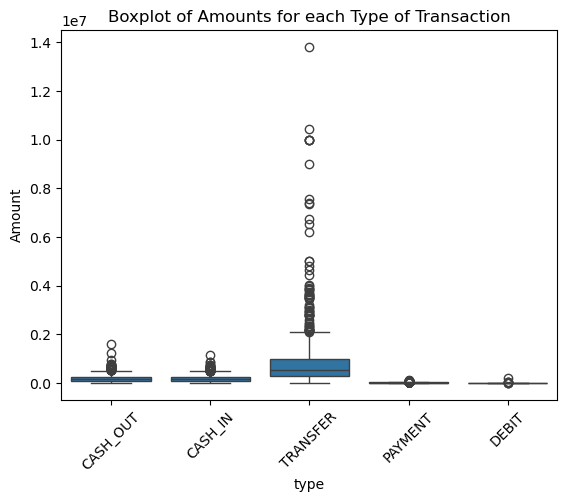

<Figure size 1000x600 with 0 Axes>

In [9]:
sns.boxplot(x ="type", y = "amount", data = df.sample(10000))
plt.title("Boxplot of Amounts for each Type of Transaction")
plt.xticks(rotation=45)
plt.ylabel("Amount")
plt.figure(figsize=(10,6))

plt.show()
#Expanding from the previous code block, I created a boxplot to visualize the 5 number summary for amounts within each type. 

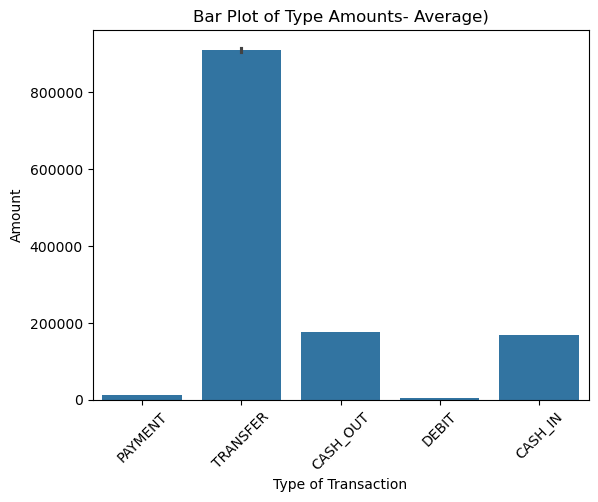

In [10]:
#The boxplot is not depicting the data well and the outliers are skewing the boxplot. I'll creat a histogram for each type to see the distrubution of the data.
sns.barplot(data = df , x = "type", y = "amount")
plt.xlabel("Type of Transaction")
plt.xticks(rotation=45)
plt.ylabel("Amount")
plt.title("Bar Plot of Type Amounts- Average)")
plt.show()

In [11]:
df.groupby("type")['amount'].mean()

type
CASH_IN     168920.242004
CASH_OUT    176273.964346
DEBIT         5483.665314
PAYMENT      13057.604660
TRANSFER    910647.009645
Name: amount, dtype: float64

In [12]:
#such a large dataset, identifying any duplicates to lessen the dataset and make it easier to analyze.
df.duplicated().sum()


np.int64(0)

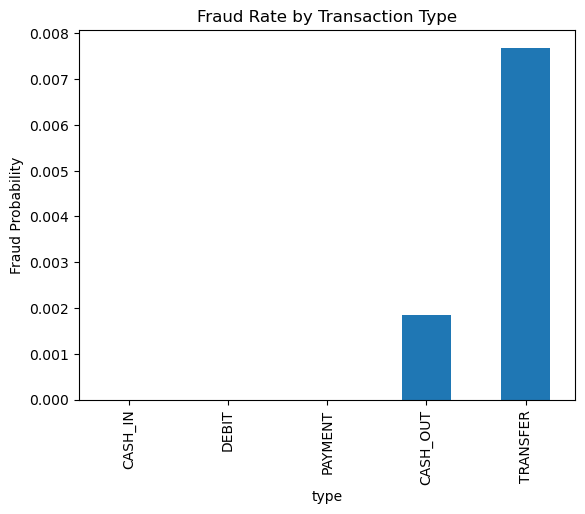

In [13]:
df.groupby("type")["isFraud"].mean().sort_values().plot(kind="bar")
plt.title("Fraud Rate by Transaction Type")
plt.ylabel("Fraud Probability")
plt.show()

Fraud is determined as:transfer funds out of a victim’s bank account before the account owner could secure their information. Cash_out and Transfer have thr highest probability of being identified as Fraud. 

In [14]:
df[(df["isFraud"] == 1) & ((df["type"] == "TRANSFER") | (df["type"] == "CASH_OUT"))].head(100)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0
251,1,TRANSFER,2806.00,C1420196421,2806.00,0.0,C972765878,0.00,0.00,1,0
252,1,CASH_OUT,2806.00,C2101527076,2806.00,0.0,C1007251739,26202.00,0.00,1,0
680,1,TRANSFER,20128.00,C137533655,20128.00,0.0,C1848415041,0.00,0.00,1,0
...,...,...,...,...,...,...,...,...,...,...,...
47145,9,CASH_OUT,350705.74,C58527359,350705.74,0.0,C582901057,894760.68,1794033.65,1,0
49825,9,TRANSFER,2539898.07,C394488466,2539898.07,0.0,C575638324,0.00,261290.69,1,0
49826,9,CASH_OUT,2539898.07,C728718059,2539898.07,0.0,C1013511446,968.00,1842864.22,1,0
49885,9,TRANSFER,361559.69,C1287719145,361559.69,0.0,C352239275,0.00,141302.12,1,0


In the previous code block, I looked at the type of transactions that are most likely to be fraud which are Cashout and Transfer and also identified as "isFraud". From this code block, isFraud amounts vary and are not only above 200,000 as per the models identifier as fraud. New model will have to a different threshold however, the bank does not want to comprimise with too many false positives. 

With 100 rows, some patterns I see are that: The "amount" of the transaction out of the "oldbalanceOrg" is all of the money in the account and the newbalanceOrig is down to zero after the transaction, transactions have not been "isFlaggedFraud"( even though some amounts are over 200,000). 

In [15]:
df[(df["isFlaggedFraud"] == 1) & ((df["type"] == "TRANSFER") | (df["type"] == "CASH_OUT"))].head(100)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2736446,212,TRANSFER,4953893.08,C728984460,4953893.08,4953893.08,C639921569,0.0,0.0,1,1
3247297,250,TRANSFER,1343002.08,C1100582606,1343002.08,1343002.08,C1147517658,0.0,0.0,1,1
3760288,279,TRANSFER,536624.41,C1035541766,536624.41,536624.41,C1100697970,0.0,0.0,1,1
5563713,387,TRANSFER,4892193.09,C908544136,4892193.09,4892193.09,C891140444,0.0,0.0,1,1
5996407,425,TRANSFER,10000000.00,C689608084,19585040.37,19585040.37,C1392803603,0.0,0.0,1,1
5996409,425,TRANSFER,9585040.37,C452586515,19585040.37,19585040.37,C1109166882,0.0,0.0,1,1
6168499,554,TRANSFER,3576297.10,C193696150,3576297.10,3576297.10,C484597480,0.0,0.0,1,1
6205439,586,TRANSFER,353874.22,C1684585475,353874.22,353874.22,C1770418982,0.0,0.0,1,1
6266413,617,TRANSFER,2542664.27,C786455622,2542664.27,2542664.27,C661958277,0.0,0.0,1,1
6281482,646,TRANSFER,10000000.00,C19004745,10399045.08,10399045.08,C1806199534,0.0,0.0,1,1


I would like to look at the patterns of transactions that have actually been identified as Fraud; I also want to see the relationship between amount,oldbalanceOrg, oldbalanceDest, newbalanceDest. However, I don't have much banking knowledge/ context but for some of the transactions the full amount is not being deposited into the newbalanceDest. Where is the rest/ all of the money being deposited? 

/opt/miniconda3/envs/ds_class/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


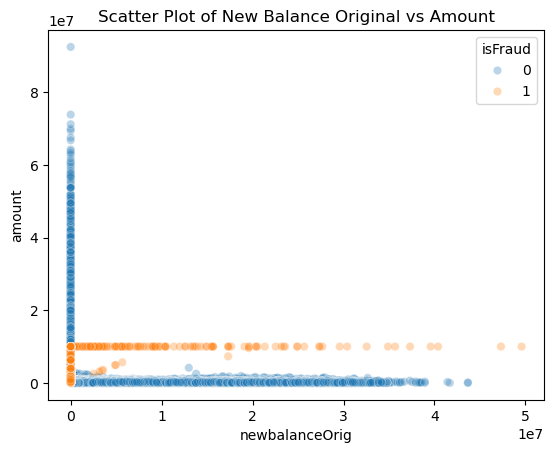

In [16]:
# I am inclined to inspect the relationship between the original account's new balance compared to the amount
sns.scatterplot(x="newbalanceOrig", y="amount", hue ="isFraud", alpha=0.3, data=df)
plt.title("Scatter Plot of New Balance Original vs Amount")
plt.show()

/opt/miniconda3/envs/ds_class/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


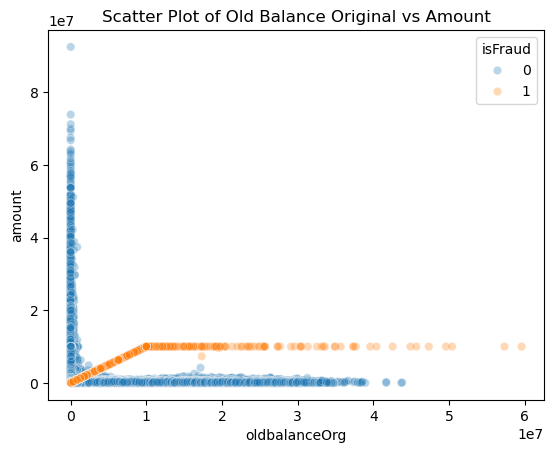

In [17]:
sns.scatterplot(x='oldbalanceOrg',y='amount', hue='isFraud',alpha=0.3,data=df)
plt.title("Scatter Plot of Old Balance Original vs Amount")
plt.show()

The strong correlation within the dataset is identified as fraud and shows the relationship between oldbalanceOrg and amount. This can be indicator to use for the model to identify more true positive fraud transactions. These amounts are not the highest but are still fraud.  

I will create a new feature called "BalanceDiff". This will be the difference between oldbalanceOrg and NewbalanceOrg. It will showcase the relationship between the balance difference and the amount. This is a strong indicator of fraud.

<Axes: >

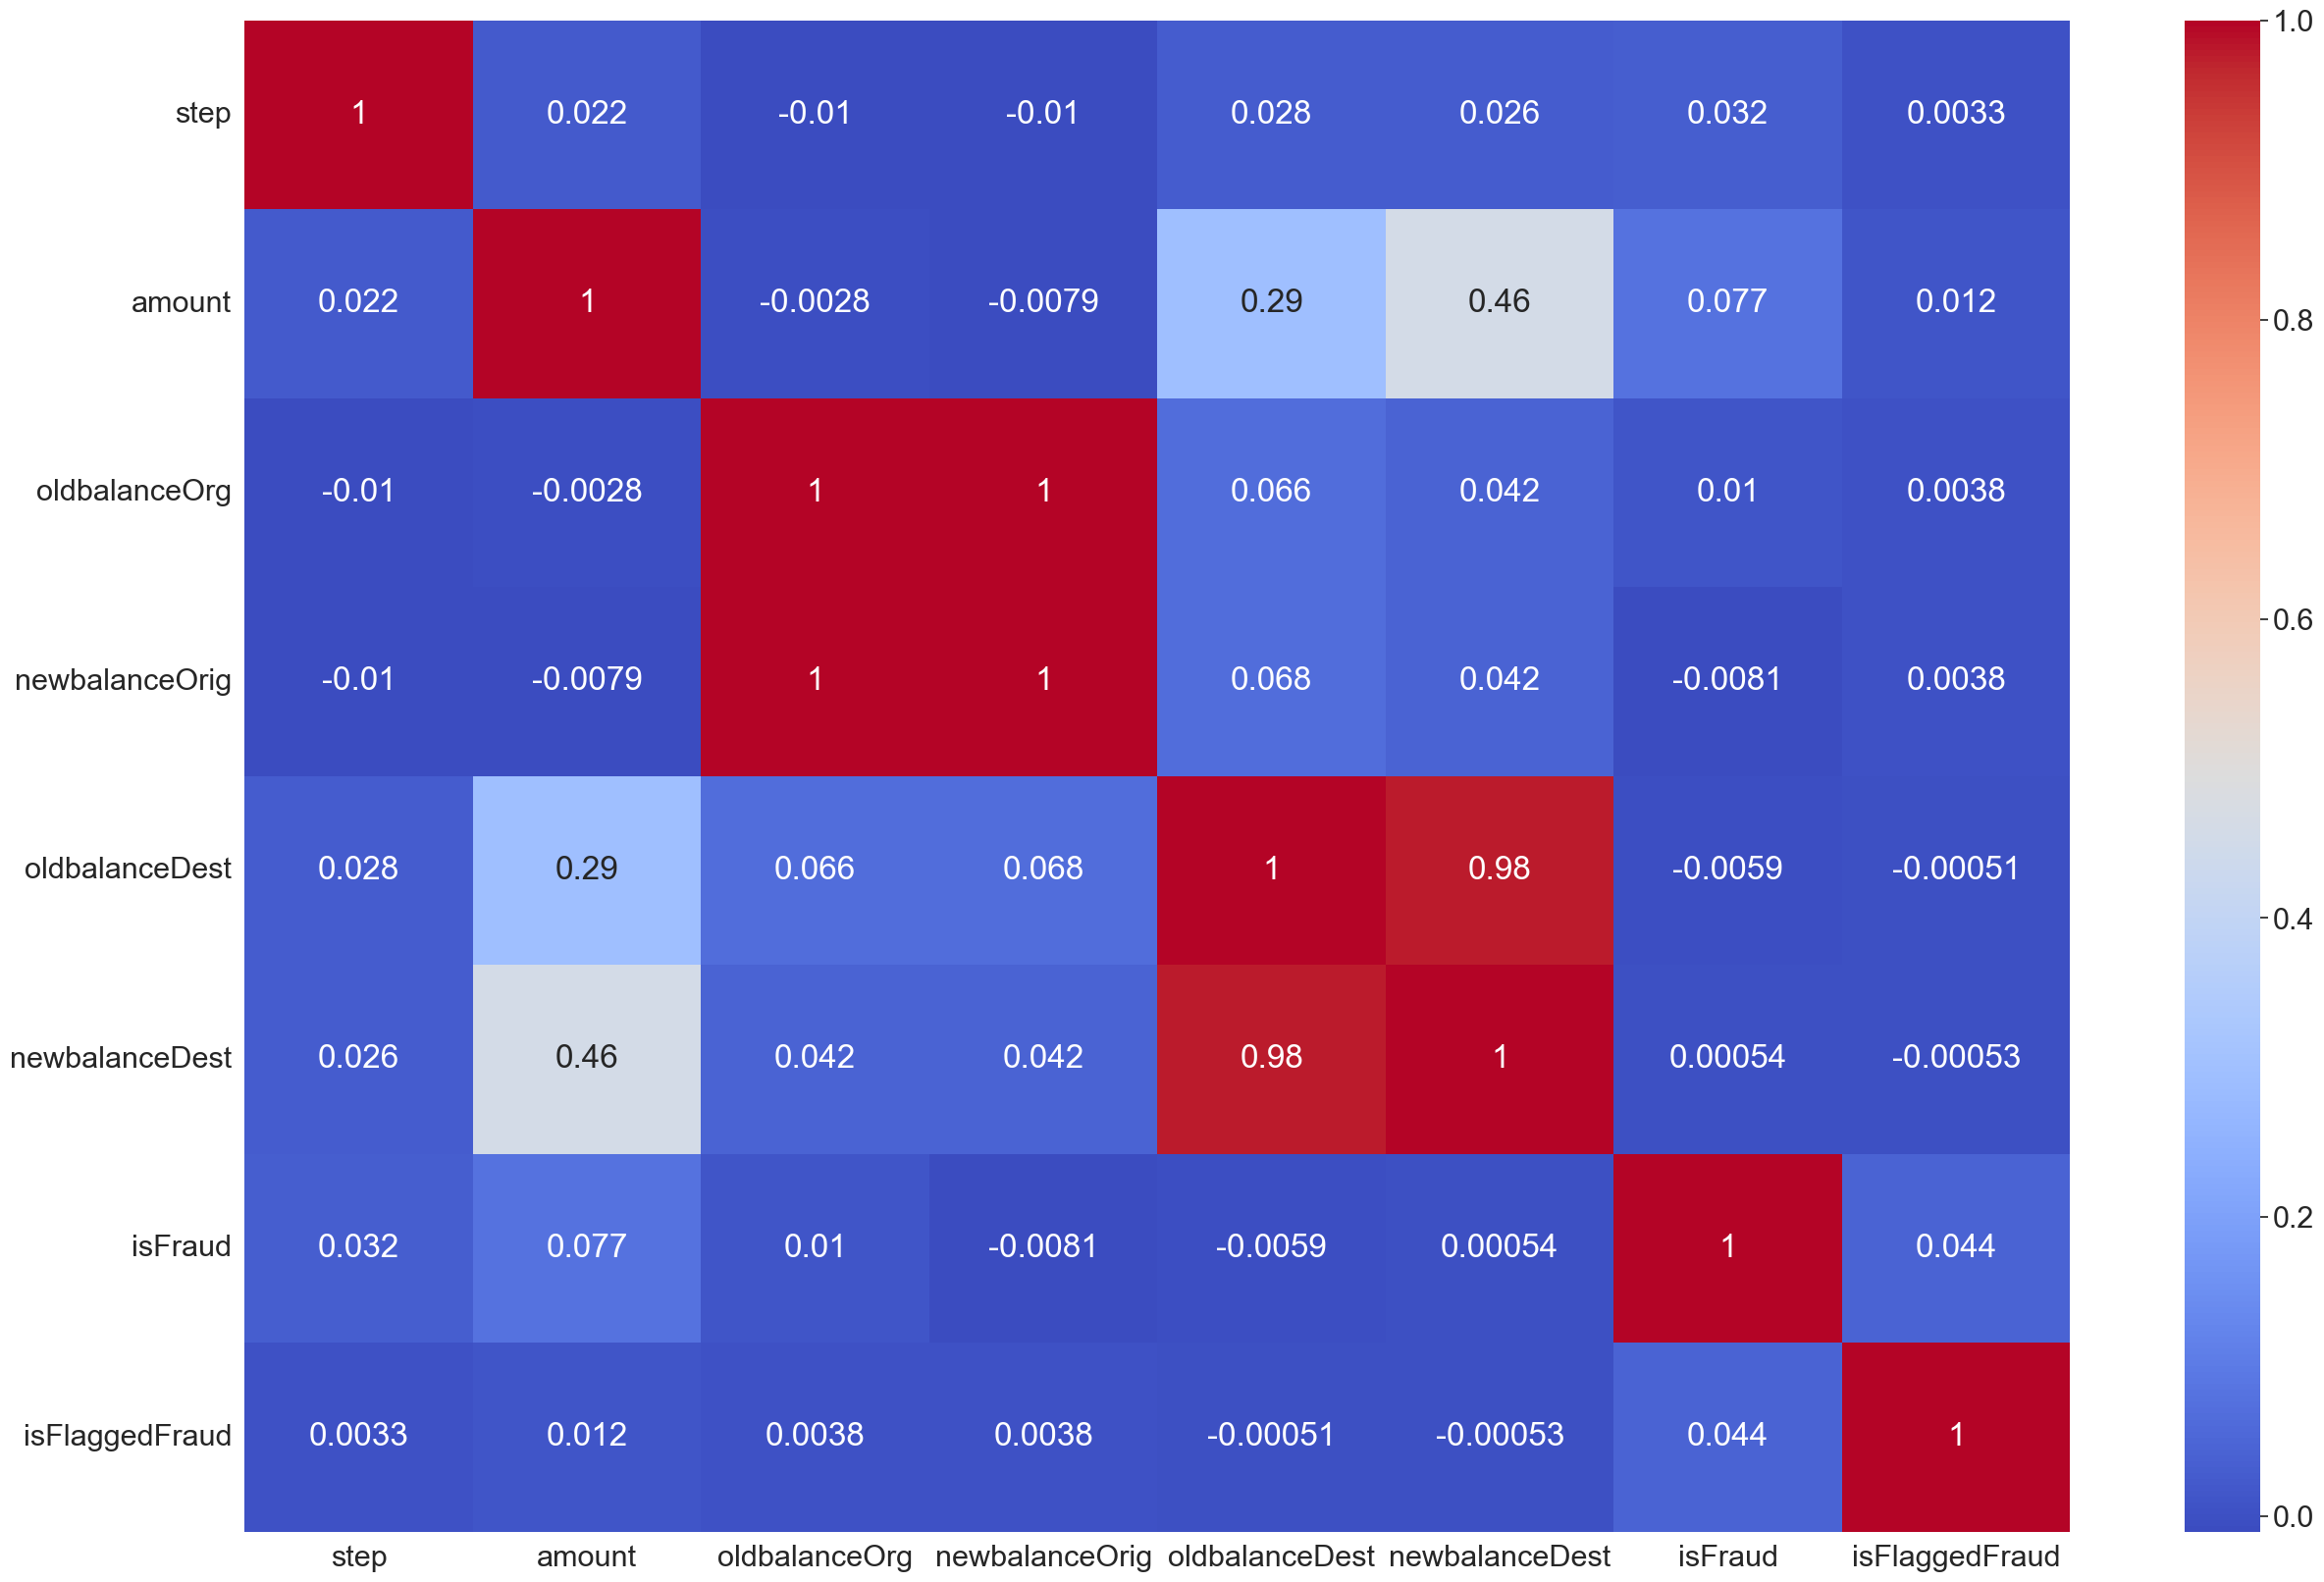

In [18]:
plt.figure(figsize = (30,20))
sns.set(font_scale = 2)
sns.heatmap(df.corr(numeric_only=True), annot = True, cmap = "coolwarm")

This heatmap shows that more of the variables are not correlated leading to less multicollinearity. The best correlation woule be the relationship between newbalanceOrg and amount. 

I also wanted to look into the relationship between the difference in newbalancedest - oldbalancedest in comparison to the amount. However, as this heatmap shows newbalancedest and oldbalancedest are highly correlated. Therefore, my previous graphs gave insight to that relationship. 

My hypothesis is that if an account is being wiped to zero no matter the amount, it is fraud. 
Null hypothesis account being wiped to zero does not mean fraud. 